In [1]:
# =====================================================================
# CELL: MULTINOMIAL NAIVE BAYES (MULTI-CLASS WITH TF-IDF)
# =====================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB


In [3]:

# 1. The Dataset (News Article Headlines)
# We have 3 distinct categories: Tech (0), Sports (1), and Medical (2)
corpus = [
    "new apple macbook pro features m3 processor",              # Tech
    "google ai algorithm improves search processor",            # Tech
    "championship finals end in penalty shootout",              # Sports
    "team wins the world cup finals in overtime",               # Sports
    "new vaccine prevents viral infection and improves health", # Medical
    "clinical trials show new drug prevents infection"          # Medical
]
# Classes: 0 = Tech, 1 = Sports, 2 = Medical
labels = np.array([0, 0, 1, 1, 2, 2])
class_names = {0: "Tech", 1: "Sports", 2: "Medical"}

In [6]:


# 2. Exploratory Data Analysis (EDA) using TF-IDF
# Instead of CountVectorizer, we use TfidfVectorizer.
# This calculates continuous decimal weights (w_i) instead of integer counts (x_i).
tfidf_vectorizer = TfidfVectorizer(stop_words='english') # Removes words like "and", "the", "in"
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

# Let's look at the actual TF-IDF weights for the first two documents
df_tfidf = pd.DataFrame(np.round(X_tfidf.toarray(), 2), columns=tfidf_vectorizer.get_feature_names_out())
print("--- EDA: TF-IDF WEIGHTS (Top 5 Words) ---")
print("Notice how these are decimals, not integers. Rare words get higher weights.")
# Displaying a subset of columns for readability
print(df_tfidf[['processor', 'finals', 'improves', 'infection', 'apple']].head(5))
print("\n")

--- EDA: TF-IDF WEIGHTS (Top 5 Words) ---
Notice how these are decimals, not integers. Rare words get higher weights.
   processor  finals  improves  infection  apple
0       0.33    0.00      0.00       0.00    0.4
1       0.35    0.00      0.35       0.00    0.0
2       0.00    0.38      0.00       0.00    0.0
3       0.00    0.34      0.00       0.00    0.0
4       0.00    0.00      0.35       0.35    0.0




In [5]:
X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 37 stored elements and shape (6, 30)>

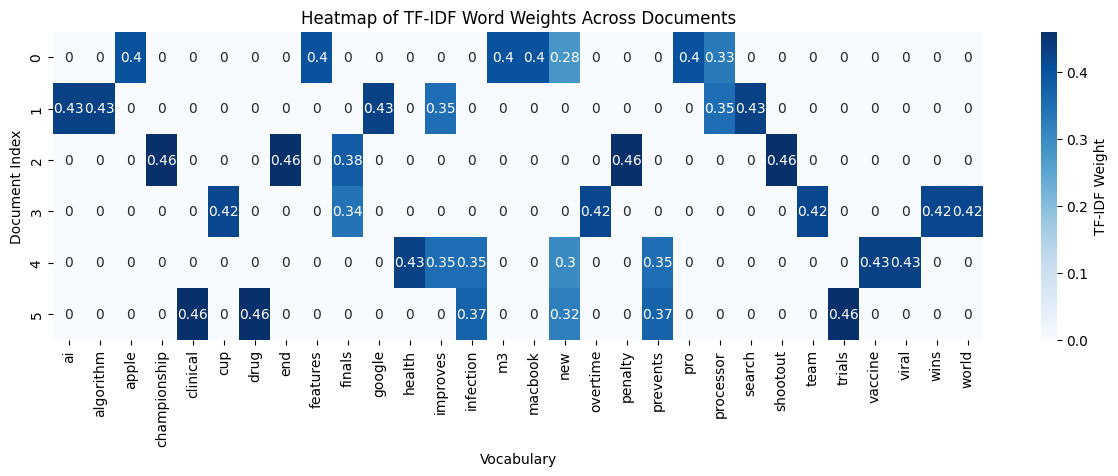

In [7]:

# Let's visualize the TF-IDF matrix using a Heatmap
plt.figure(figsize=(15, 4))
sns.heatmap(df_tfidf, cmap="Blues", annot=True, cbar_kws={'label': 'TF-IDF Weight'})
plt.title("Heatmap of TF-IDF Word Weights Across Documents")
plt.xlabel("Vocabulary")
plt.ylabel("Document Index")
plt.show()


In [8]:


# 3. Prepare and Train the Model
# MultinomialNB natively handles both multi-class targets and continuous TF-IDF inputs.
# It simply sums the decimal weights instead of counting integers.
multi_tfidf_model = MultinomialNB(alpha=0.5) # alpha is our Laplace Smoothing
multi_tfidf_model.fit(X_tfidf, labels)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.5
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [12]:

# 4. Manual Input and Prediction
# Let's test a brand new headline that shares words across different domains.
# "improves" is in Tech and Medical. "processor" is in Tech.
manual_headline = ["new clinical  processor speed trails new "]

# Transform the raw text into a TF-IDF vector based on the training vocabulary
manual_vector = tfidf_vectorizer.transform(manual_headline)

# Execute the prediction
prediction = multi_tfidf_model.predict(manual_vector)
probabilities = multi_tfidf_model.predict_proba(manual_vector)

print("--- MULTI-CLASS PREDICTION RESULTS ---")
print(f"Input Headline: '{manual_headline[0]}'")
print(f"Predicted Category: {class_names[prediction[0]]}")
print("\nProbability Breakdown:")
for i, prob in enumerate(probabilities[0]):
    print(f"- {class_names[i]}: {prob * 100:.2f}%")

--- MULTI-CLASS PREDICTION RESULTS ---
Input Headline: 'new clinical  processor speed trails new '
Predicted Category: Medical

Probability Breakdown:
- Tech: 36.09%
- Sports: 18.57%
- Medical: 45.34%
